In [11]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
print(connection)

Authenticated using refresh token.
<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>


In [12]:
import geopandas as gpd
import Functions
import os
import pandas as pd


app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Data' / 'Ground_Campaign'
ndvi = app_path / 'Documents' / 'csv' / 'NDVI'
parcels = pd.read_csv(app_path / 'Documents' / 'csv' / 'areas_Flavoland.csv', index_col=0)

shape_path = input_path / 'Flevoland_data' / 'Data_25_fields' / 'Flevoland-fields-Shapefiles' / 'Feloveland-fields-Shapefiles'
shapes = list(shape_path.glob('*.shp'))
display(parcels)

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA


,Area_KM2,Code,Type,Unnamed: 4
Name,,,,
NaN,NaN,NaN,NaN,NaN
PE_A2_C,0.062289,1889479.0,Aardappelen,consumptie
PE_A3_C,0.050043,1697691.0,Aardappelen,consumptie
PE_A4_C,0.078363,1889482.0,Aardappelen,consumptie
PVD-M-C,0.090290,2278835.0,Maïs,snij-
RBW_A_C,0.078939,2081268.0,Aardappelen,consumptie
RBW_SB,0.079957,1601502.0,Bieten,suiker-
RBW_T_C,0.081114,2081267.0,Tarwe,winter-
SB10_MA_C,0.137161,2081887.0,Maïs,snij-


In [18]:
import geopandas as gpd
import Functions
import os
import pandas as pd


app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Data' / 'Ground_Campaign'
ndvi = app_path / 'Documents' / 'csv' / 'NDVI'
#parcels = pd.read_csv(app_path / 'Documents'/ )

shape_path = input_path / 'Flevoland_data' / 'Data_25_fields' / 'Flevoland-fields-Shapefiles' / 'Feloveland-fields-Shapefiles'
shapes = list(shape_path.glob('*.shp'))


for i in shapes:

    try:
        gdf = gpd.read_file(i)

        if gdf.empty or gdf.geometry.isnull().all():
            print(f"⚠️ Attenzione: Il file {i} è leggibile ma vuoto. Salto.")
            continue
            
        # Assicurati che sia in WGS84
        if gdf.crs != "EPSG:4326":
            gdf = gdf.to_crs("EPSG:4326")
            
        spatial_extent = gdf.union_all().__geo_interface__
        
        # --- Qui metti la tua logica openEO ---
        datacube = connection.load_collection(
            "SENTINEL2_L2A",
            spatial_extent=spatial_extent,
            temporal_extent=["2017-01-03", "2017-12-31"],
            bands=["B04", "B08"],
            properties={
                "eo:cloud_cover": lambda c: c <= 10
            }
        )

        ndvi_cube = datacube.ndvi(nir="B08", red="B04")
        stats_cube = ndvi_cube.aggregate_spatial(
            geometries=spatial_extent,
            reducer="mean"
        )
        dati_grafico = stats_cube.execute()

        records = []
        for data_str, valori in dati_grafico.items():
            # Estraiamo il primo valore numerico dalla lista [valore]
            valore_ndvi = valori[0][0] if valori else None 
            
            records.append({
                "Data": pd.to_datetime(data_str).date(), # Converte in formato data (AAAA-MM-GG)
                "NDVI_Medio": valore_ndvi
            })

        # 2. Creiamo il DataFrame Pandas
        df = pd.DataFrame(records)

        # 3. Ordiniamo cronologicamente (giusto per sicurezza)
        df = df.sort_values(by="Data").reset_index(drop=True)

        # Mostra il risultato a schermo
        df.dropna(inplace=True)
        df = df[df['NDVI_Medio']>0.1].dropna()

        df.to_csv(app_path / 'Documents' /'csv' / 'NDVI' / f'{os.path.basename(i)}.csv', index=False ) 



        # Esempio: scarica o elabora...
        print(f"✅ File {os.path.basename(i)} elaborato con successo su openEO!")
        
    except Exception as e:
        # Se capita QUALSIASI errore (file corrotto, componenti mancanti, ecc.)
        # il codice entra qui, stampa l'errore e va avanti con il prossimo file
        print(f"❌ ERRORE: Impossibile leggere o elaborare {os.path.basename(i)}.")
        print(f"Dettaglio errore: {e}")
        print("Salto al file successivo...")
        continue


path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA
✅ File DB_A_C.shp elaborato con successo su openEO!
✅ File AKW_SB_C.shp elaborato con successo su openEO!
❌ ERRORE: Impossibile leggere o elaborare HF2-SB_C.shp.
Dettaglio errore: Unable to open /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Data/Ground_Campaign/Flevoland_data/Data_25_fields/Flevoland-fields-Shapefiles/Feloveland-fields-Shapefiles/HF2-SB_C.shx or /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Data/Ground_Campaign/Flevoland_data/Data_25_fields/Flevoland-fields-Shapefiles/Feloveland-fields-Shapefiles/HF2-SB_C.SHX. Set SHAPE_RESTORE_SHX config option to YES to restore or create it.
Salto al file successivo...
✅ File KL_MA_1_C.shp elaborato con successo su openEO!
✅ File HF3_WT_C.shp elaborato con successo su openEO!
✅ File PE_A4_C.shp elaborato con successo su openEO!
✅ File SB7_ER_C.shp elaborato con successo su openEO!
✅ File KL_MA2-C.shp elaborato con successo su openEO!
✅ File PVD-

In [19]:
records = []
for data_str, valori in dati_grafico.items():
    # Estraiamo il primo valore numerico dalla lista [valore]
    valore_ndvi = valori[0][0] if valori else None 
    
    records.append({
        "Data": pd.to_datetime(data_str).date(), # Converte in formato data (AAAA-MM-GG)
        "NDVI_Medio": valore_ndvi
    })

# 2. Creiamo il DataFrame Pandas
df = pd.DataFrame(records)

# 3. Ordiniamo cronologicamente (giusto per sicurezza)
df = df.sort_values(by="Data").reset_index(drop=True)

# Mostra il risultato a schermo
df.dropna(inplace=True)
df = df[df['NDVI_Medio']>0.1].dropna()
display(df.iloc[0:50])

,Data,NDVI_Medio
0,2017-01-26,0.172490
1,2017-02-15,0.162849
2,2017-05-11,0.141424
3,2017-05-26,0.314379
4,2017-08-29,0.835120
5,2017-09-23,0.668620
6,2017-10-15,0.594819
7,2017-11-07,0.368510


In [20]:
import geopandas as gpd
import Functions
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Data' / 'Ground_Campaign'
ndvi = app_path / 'Documents' / 'csv' / 'NDVI'

ndvis = list(ndvi.glob('*.csv'))
ratio = pd.read_csv(app_path/'Documents'/ 'csv'/'ratio.csv', index_col=0)
print(len(ndvis))

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA
49


,NDVI_Medio
Data,
2017-01-26,0.186646
2017-02-15,0.141659
2017-05-11,0.142262
2017-05-26,0.256445
2017-08-29,0.769644
2017-09-23,0.692752
2017-10-15,0.666760
2017-11-07,0.689883


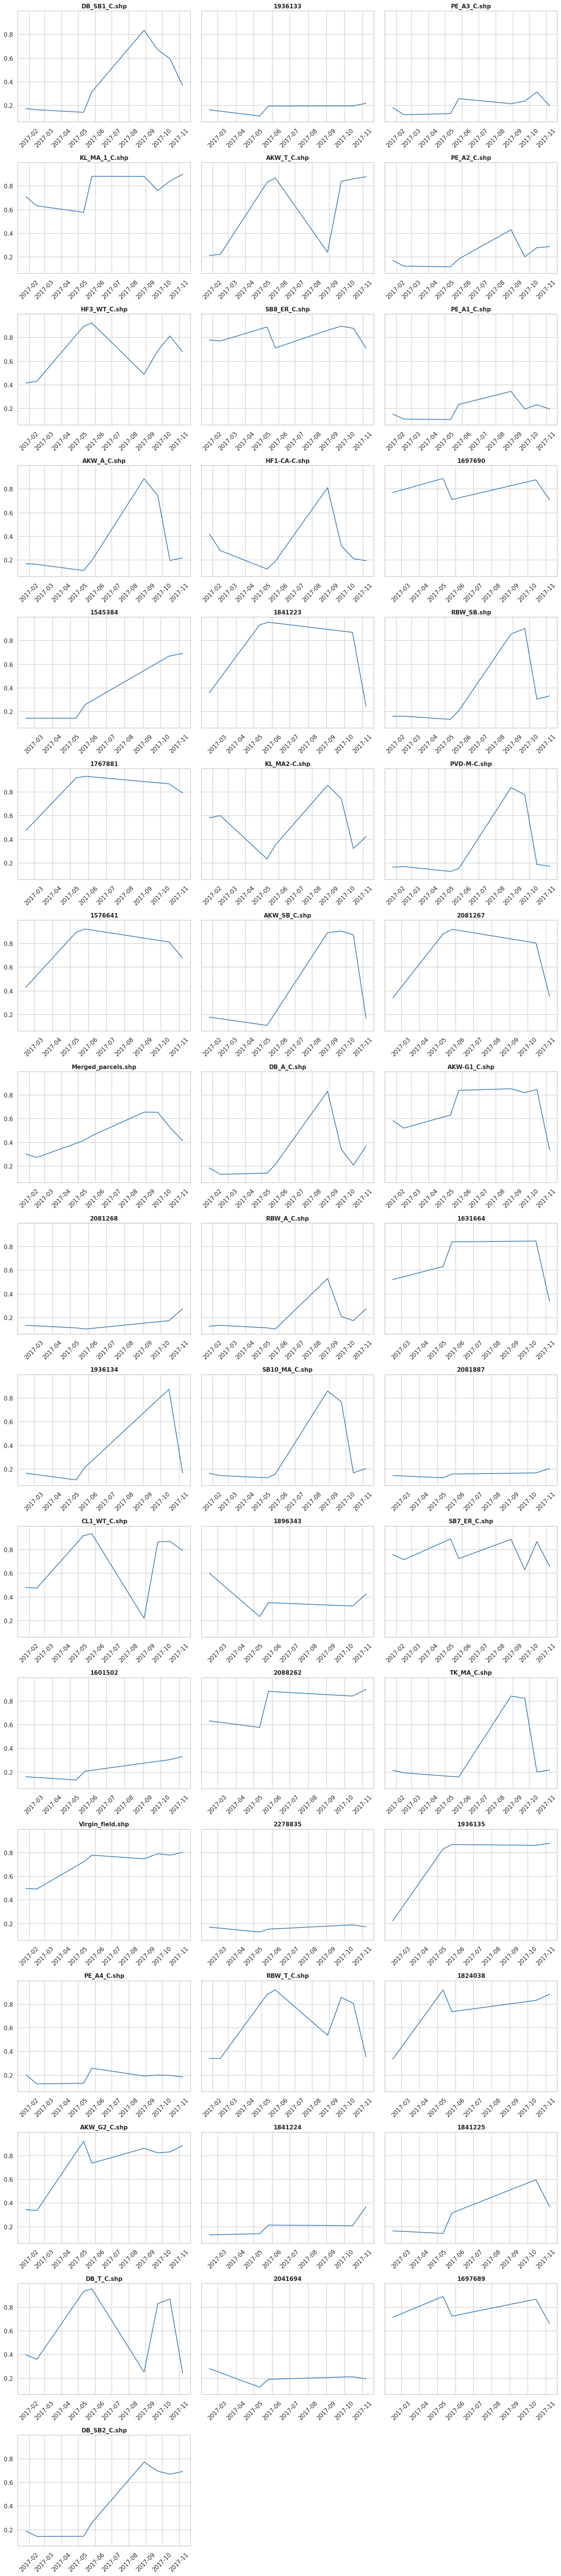

In [21]:
num_file = len(ndvis)
colonne = 3  
righe = int(np.ceil(num_file / colonne)) 

# --- 2. CREAZIONE DELLA GRIGLIA VUOTA ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(
    righe, colonne, figsize=(5 * colonne, 4 * righe), sharey=True)
axes_piatti = axes.flatten()

for i, file in enumerate(ndvis):
    nome_file = os.path.basename(file).replace(".csv", "")

    df = pd.read_csv(file, parse_dates=True, index_col='Data')

    ax_corrente = axes_piatti[i]
    ax_corrente.plot(df.index, df['NDVI_Medio'], color="steelblue", linewidth=1.5)
    ax_corrente.set_title(nome_file, fontsize=11, fontweight="bold")
    ax_corrente.tick_params(axis="x", rotation=45)

for j in range(num_file, len(axes_piatti)):
    fig.delaxes(axes_piatti[j])
    

# Ottimizza gli spazi per evitare che i titoli o le date si sovrappongano tra i grafici
plt.tight_layout()

display(df)